In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Dataset paths
REAL_PATH = "/content/drive/Shareddrives/Accurate Files/AIS Projects/Fake Video Detection/Dataset/real"
FAKE_PATH = "/content/drive/Shareddrives/Accurate Files/AIS Projects/Fake Video Detection/Dataset/fake"
OUTPUT_FRAME_SIZE = (128, 128)  # Frame dimensions
FRAME_COUNT = 10  # Number of frames to extract per video


# Function to extract frames from a video
def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)  # Uniform sampling

    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, output_size)
        frames.append(frame)
    cap.release()
    return np.array(frames)


# Prepare data and labels
data = []
labels = []

# Process real videos
print("Processing real videos...")
for video_file in tqdm(os.listdir(REAL_PATH)):
    video_path = os.path.join(REAL_PATH, video_file)
    frames = extract_frames(video_path, output_size=OUTPUT_FRAME_SIZE, frame_count=FRAME_COUNT)
    if len(frames) == FRAME_COUNT:  # Ensure correct frame count
        data.append(frames)
        labels.append(0)  # Label 0 for real

# Process fake videos
print("Processing fake videos...")
for video_file in tqdm(os.listdir(FAKE_PATH)):
    video_path = os.path.join(FAKE_PATH, video_file)
    frames = extract_frames(video_path, output_size=OUTPUT_FRAME_SIZE, frame_count=FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(1)  # Label 1 for fake

# Convert to numpy arrays
data = np.array(data)  # Shape: (num_videos, num_frames, 128, 128, 3)
labels = np.array(labels)

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize data
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# Convert labels to categorical
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

print(f"Data shapes: Train - {X_train.shape}, Validation - {X_val.shape}, Test - {X_test.shape}")

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augment frames
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Function to augment extracted frames
def augment_frames(frames):
    augmented_frames = []
    for frame in frames:
        frame = datagen.random_transform(frame)
        augmented_frames.append(frame)
    return np.array(augmented_frames)

# Augment training data
augmented_data = []
augmented_labels = []

for i in range(len(X_train)):
    augmented_frames = augment_frames(X_train[i])
    augmented_data.append(augmented_frames)
    augmented_labels.append(y_train[i])

# Combine original and augmented data
X_train_augmented = np.concatenate((X_train, np.array(augmented_data)))
y_train_augmented = np.concatenate((y_train, np.array(augmented_labels)))

print(f"Augmented Train Data: {X_train_augmented.shape}")


import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Flatten, TimeDistributed, LSTM
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dropout

# Define model
def build_improved_model(input_shape=(FRAME_COUNT, 128, 128, 3)):
    model = Sequential([
        TimeDistributed(Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))),
        TimeDistributed(Flatten()),
        Dropout(0.5),  # Add dropout for regularization
        LSTM(128, return_sequences=False),
        Dropout(0.5),  # Add dropout
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_improved_model()
model.summary()



from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Model checkpoint to save the best model in .keras format
checkpoint = ModelCheckpoint(
    "deepfake_detection_model.keras",  # Change to .keras
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Reduce learning rate on plateau
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_augmented, y_train_augmented,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=10,
    callbacks=[checkpoint, lr_scheduler]
)
model.save("deepfake_detection_model.keras")

Processing real videos...


100%|██████████| 100/100 [20:18<00:00, 12.19s/it]


Processing fake videos...


100%|██████████| 100/100 [19:09<00:00, 11.49s/it]


Data shapes: Train - (140, 10, 128, 128, 3), Validation - (30, 10, 128, 128, 3), Test - (30, 10, 128, 128, 3)
Augmented Train Data: (280, 10, 128, 128, 3)
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.5588 - loss: 0.7347
Epoch 1: val_accuracy improved from -inf to 0.60000, saving model to deepfake_detection_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5587 - loss: 0.7349 - val_accuracy: 0.6000 - val_loss: 0.6579 - learning_rate: 1.0000e-04
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.5971 - loss: 0.6608
Epoch 2: val_accuracy did not improve from 0.60000
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 802ms/step - accuracy: 0.5963 - loss: 0.6608 - val_accuracy: 0.5000 - val_loss: 0.7063 - learning_rate: 1.0000e-04
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.6020 - loss: 0.6138
Epoch 3: val_accuracy improved from 0.60000 to 0.80000, saving model to deepfake_detection_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 44s 911ms/step - accuracy: 0.6014 - loss: 0.6150 - val_accuracy: 0.8000 - val_loss: 0.4972 - learning_rate: 1.0000e-04
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - accuracy: 0.9000 - loss: 0.3148


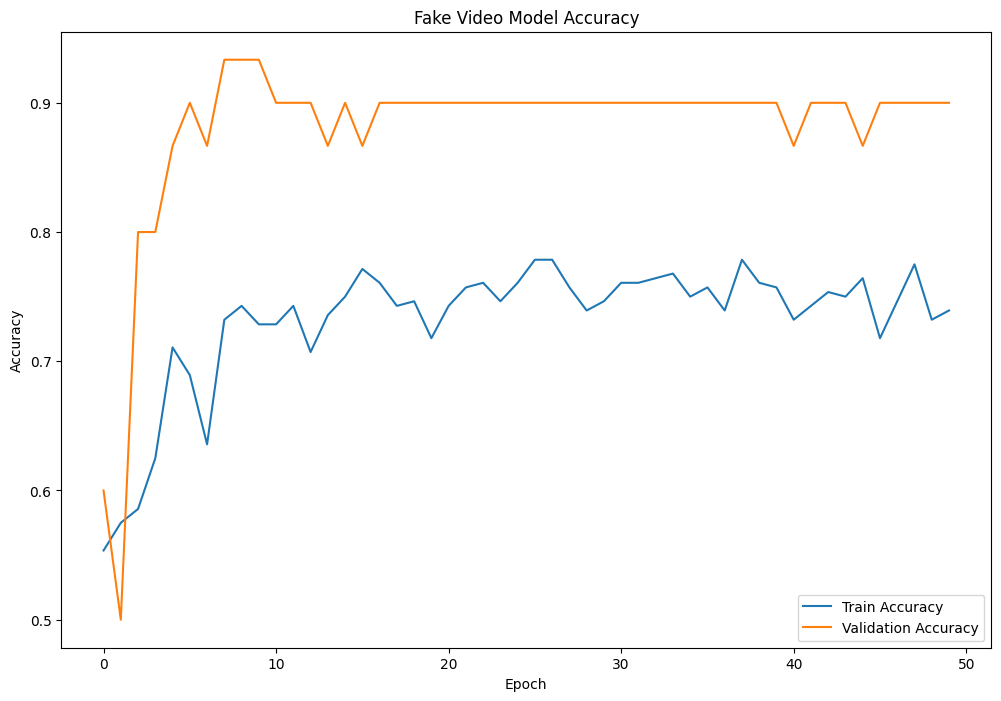

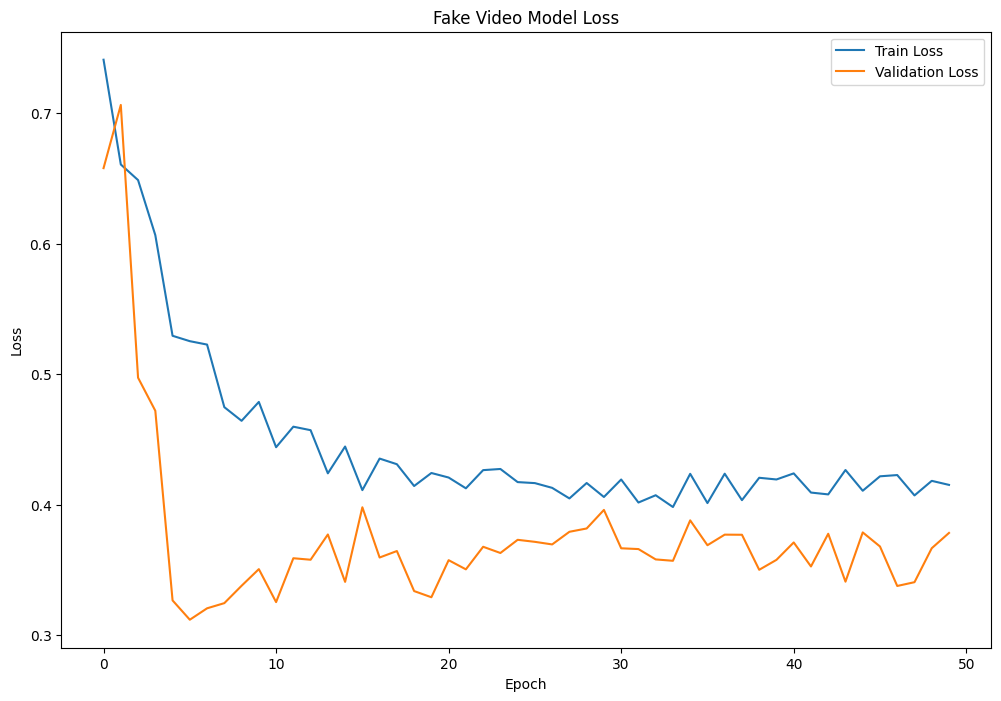

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step


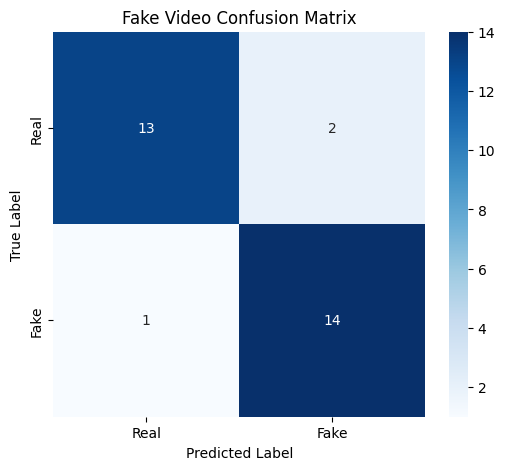

(0.31483909487724304, 0.8999999761581421)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 8))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fake Video Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Fake Video Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Fake Video Confusion Matrix')
plt.show()

# Display test accuracy and loss
test_loss, test_accuracy
